In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
prices = pd.read_csv("data/dk2_prices.csv", parse_dates=["TimeDK"])
prices.head()

,TimeUTC,TimeDK,PriceArea,DayAheadPriceEUR,DayAheadPriceDKK
0,2026-09-14 21:45:00,2026-09-14 23:45:00,DK2,205.949997,1539.435038
1,2026-09-14 21:30:00,2026-09-14 23:30:00,DK2,217.410004,1625.096298
2,2026-09-14 21:15:00,2026-09-14 23:15:00,DK2,222.990005,1666.805689
3,2026-09-14 21:00:00,2026-09-14 23:00:00,DK2,234.509995,1752.915311
4,2026-09-14 20:45:00,2026-09-14 22:45:00,DK2,225.949997,1688.931038


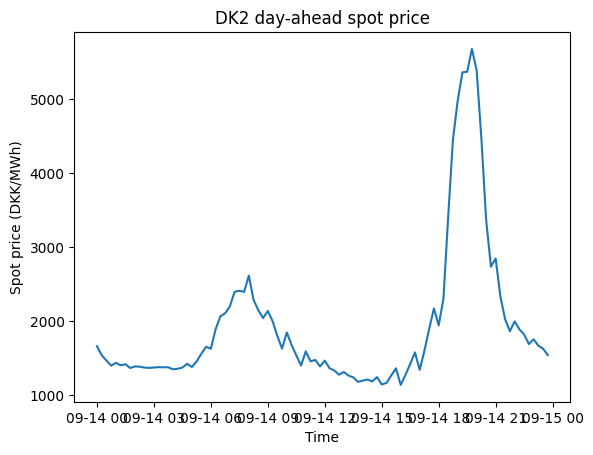

In [3]:
plt.plot(prices["TimeDK"], prices["DayAheadPriceDKK"])
plt.xlabel("Time")
plt.ylabel("Spot price (DKK/MWh)")
plt.title("DK2 day-ahead spot price")
plt.show()

In [4]:
wind = pd.read_csv("data/dk2_wind.csv", parse_dates=["Minutes5DK"])
wind["TotalWindPower"] = wind["OffshoreWindPower"] + wind["OnshoreWindPower"]
wind.head()

,Minutes5UTC,Minutes5DK,PriceArea,ProductionLt100MW,ProductionGe100MW,OffshoreWindPower,OnshoreWindPower,SolarPower,ExchangeGreatBelt,ExchangeGermany,ExchangeNetherlands,ExchangeGreatBritain,ExchangeNorway,ExchangeSweden,BornholmSE4,TotalWindPower
0,2026-09-14 21:55:00,2026-09-14 23:55:00,DK2,78.040001,601.969971,86.639999,22.440001,0.0,197.369995,-65.730003,NaN,NaN,NaN,410.890015,33.959999,109.080000
1,2026-09-14 21:50:00,2026-09-14 23:50:00,DK2,78.489998,594.799988,84.639999,22.870001,0.0,185.899994,-44.540001,NaN,NaN,NaN,390.730011,33.730000,107.510000
2,2026-09-14 21:45:00,2026-09-14 23:45:00,DK2,76.330002,595.260010,81.360001,22.190001,0.0,221.399994,-69.669998,NaN,NaN,NaN,419.739990,14.100000,103.550002
3,2026-09-14 21:40:00,2026-09-14 23:40:00,DK2,77.040001,576.989990,73.919998,22.719999,0.0,248.500000,-56.820000,NaN,NaN,NaN,417.559998,33.860001,96.639997
4,2026-09-14 21:35:00,2026-09-14 23:35:00,DK2,81.480003,561.789978,65.750000,22.680000,0.0,248.419998,-30.070000,NaN,NaN,NaN,398.660004,34.000000,88.430000


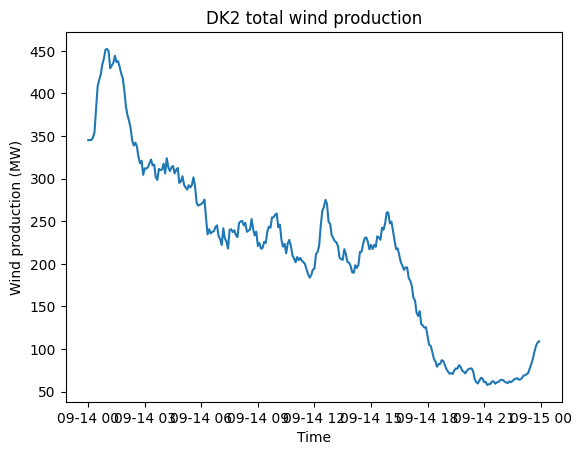

In [5]:
plt.plot(wind["Minutes5DK"], wind["TotalWindPower"])
plt.xlabel("Time")
plt.ylabel("Wind production (MW)")
plt.title("DK2 total wind production")
plt.show()

In [6]:
print("Price date range:", prices["TimeDK"].min(), "to", prices["TimeDK"].max())
print("Wind date range:", wind["Minutes5DK"].min(), "to", wind["Minutes5DK"].max())

Price date range: 2026-09-14 00:00:00 to 2026-09-14 23:45:00
Wind date range: 2026-09-14 00:00:00 to 2026-09-14 23:55:00


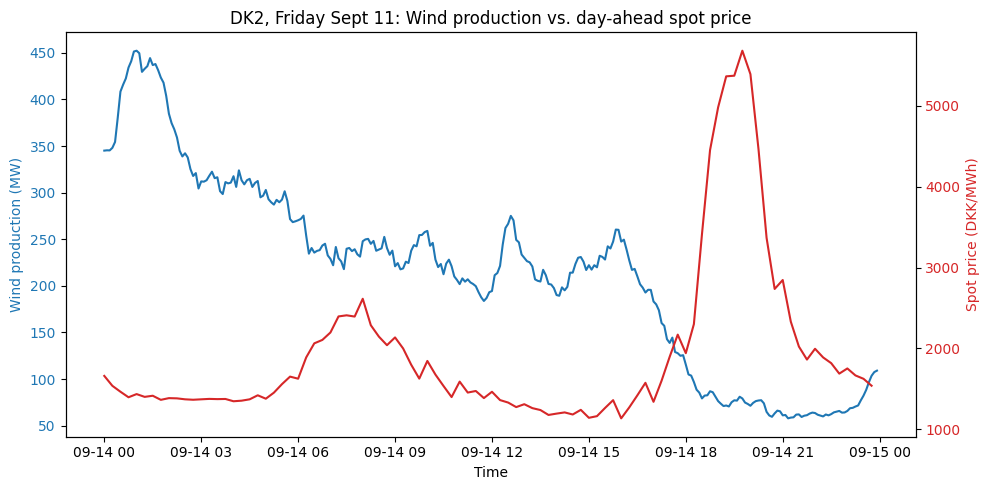

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(wind["Minutes5DK"], wind["TotalWindPower"], color="tab:blue", label="Wind production (MW)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Wind production (MW)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(prices["TimeDK"], prices["DayAheadPriceDKK"], color="tab:red", label="Spot price (DKK/MWh)")
ax2.set_ylabel("Spot price (DKK/MWh)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("DK2, Friday Sept 11: Wind production vs. day-ahead spot price")
fig.tight_layout()
plt.savefig("data/wind_vs_price.png")
plt.show()